In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("sales_dataset.csv", low_memory=False)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sales_dataset.csv to sales_dataset.csv


In [6]:
df.shape

df.info()

df.head()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [7]:
df.drop(columns=['Unnamed: 22'], inplace=True)

In [8]:
df['Amount'].fillna(df['Amount'].median(), inplace=True)

/tmp/ipykernel_3271/1929668704.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(df['Amount'].median(), inplace=True)


In [9]:
df['currency'].fillna(df['currency'].mode()[0], inplace=True)

/tmp/ipykernel_3271/2643627603.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['currency'].fillna(df['currency'].mode()[0], inplace=True)


In [10]:
df['fulfilled-by'].fillna("Merchant", inplace=True)

/tmp/ipykernel_3271/1059145231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fulfilled-by'].fillna("Merchant", inplace=True)


In [11]:
df['Courier Status'].fillna("Unknown", inplace=True)

/tmp/ipykernel_3271/3645568434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier Status'].fillna("Unknown", inplace=True)


In [12]:
df.duplicated().sum()

np.int64(6)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_3271/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [15]:
df.dtypes

,0
Order ID,object
Date,datetime64[ns]
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Style,object
SKU,object
Category,object
Size,object


In [16]:
df['Qty'].describe()

df['Amount'].describe()

,Amount
count,128943.000000
mean,645.914031
std,272.785604
min,0.000000
25%,459.000000
50%,605.000000
75%,771.000000
max,5584.000000


In [17]:
df[df['Qty'] < 0]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by


In [18]:
df[df['Amount'] < 0]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by


<Axes: ylabel='Amount'>

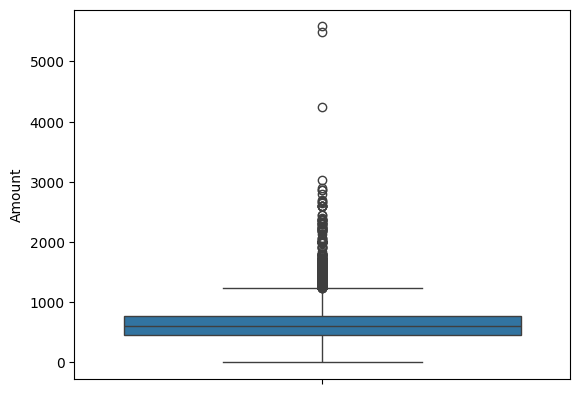

In [19]:
import seaborn as sns

sns.boxplot(df['Amount'])

<Axes: ylabel='Qty'>

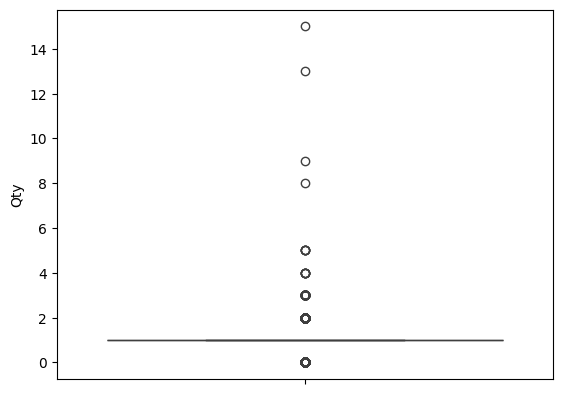

In [20]:
sns.boxplot(df['Qty'])

In [21]:
df['ship-state'] = df['ship-state'].str.title()

df['ship-city'] = df['ship-city'].str.title()

df['Category'] = df['Category'].str.title()

In [22]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


data modelling/Feature enginee

In [23]:
df['Year'] = df['Date'].dt.year

In [24]:
df['Month No'] = df['Date'].dt.month

In [25]:
df['Month'] = df['Date'].dt.month_name()

In [26]:
df['Day'] = df['Date'].dt.day_name()

In [27]:
df['Quarter'] = df['Date'].dt.quarter

In [28]:
df['Week'] = df['Date'].dt.isocalendar().week

In [29]:
df['Weekend'] = np.where(df['Day'].isin(['Saturday','Sunday']), 'Yes', 'No')

In [30]:
df['Order Type'] = np.where(df['B2B'], 'B2B', 'B2C')

In [31]:
df['Revenue'] = df['Amount']

In [32]:
df['ASP'] = df['Amount'] / df['Qty']

In [33]:
df['ASP'] = np.where(df['Qty'] == 0, 0, df['Amount'] / df['Qty'])

In [34]:
df['Status Group'] = np.where(
    df['Status'].str.contains('Cancelled', case=False),
    'Cancelled',
    'Completed'
)

In [35]:
df['Promotion Used'] = np.where(
    df['promotion-ids'] == 'No Promotion',
    'No',
    'Yes'
)

In [36]:
df['Shipping Mode'] = df['ship-service-level']

In [37]:
df.info()

df.head()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 128943 entries, 0 to 128948
Data columns (total 35 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128943 non-null  object        
 1   Date                128943 non-null  datetime64[ns]
 2   Status              128943 non-null  object        
 3   Fulfilment          128943 non-null  object        
 4   Sales Channel       128943 non-null  object        
 5   ship-service-level  128943 non-null  object        
 6   Style               128943 non-null  object        
 7   SKU                 128943 non-null  object        
 8   Category            128943 non-null  object        
 9   Size                128943 non-null  object        
 10  ASIN                128943 non-null  object        
 11  Courier Status      128943 non-null  object        
 12  Qty                 128943 non-null  int64         
 13  currency            128943 non-nul

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


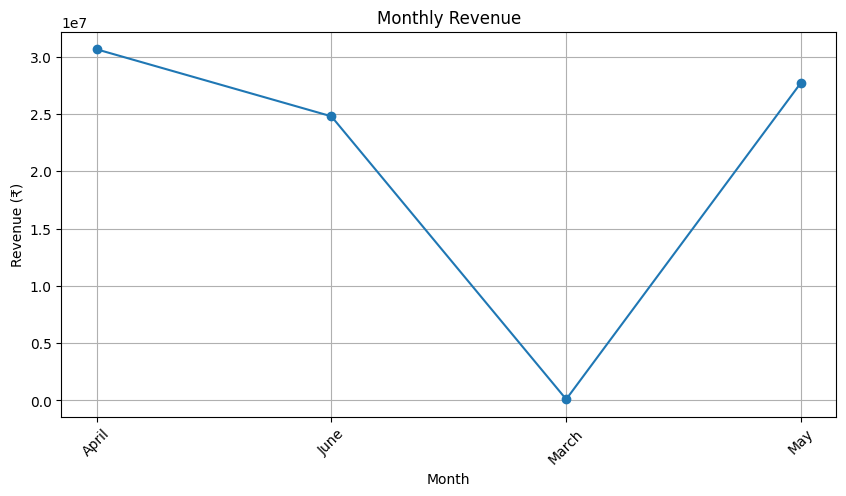

In [38]:
monthly_sales = df.groupby('Month')['Amount'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Amount'], marker='o')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Insight: Shows seasonality and revenue growth over time.

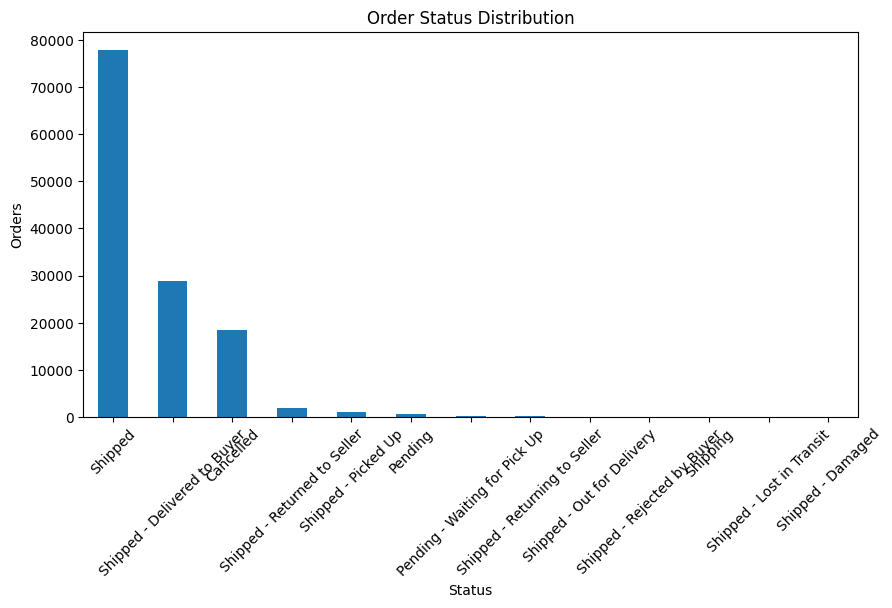

In [39]:
plt.figure(figsize=(10,5))
df['Status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

Insight: Compare Delivered, Cancelled, Returned, etc.

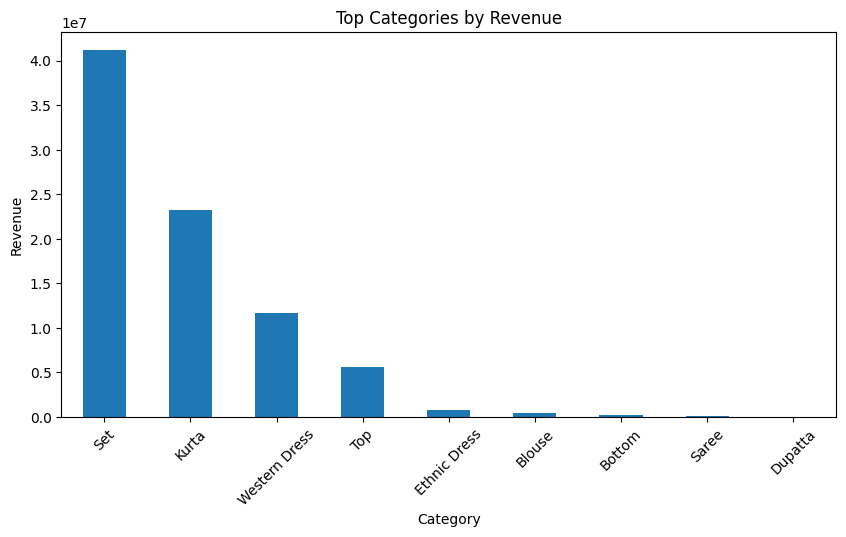

In [40]:
top_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_category.plot(kind='bar')
plt.title("Top Categories by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Insight: Identifies the highest revenue-generating categories.

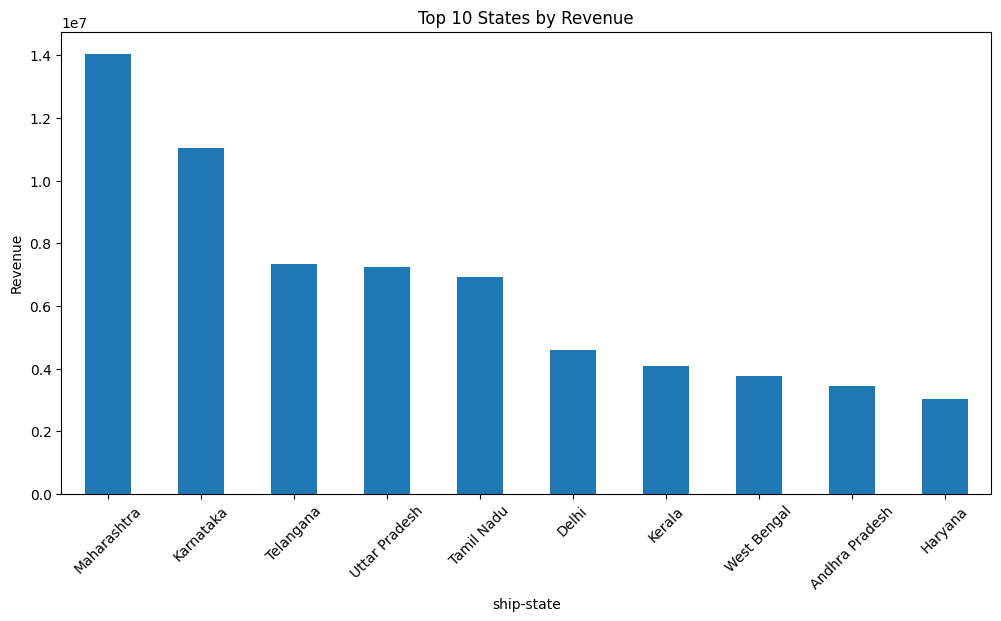

In [41]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Insight: Highlights the best-performing regions.

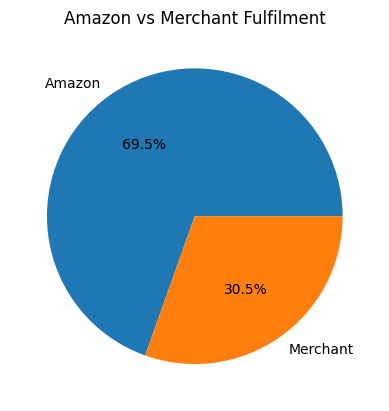

In [42]:
df['Fulfilment'].value_counts().plot(kind='pie',autopct='%1.1f%%')

plt.title("Amazon vs Merchant Fulfilment")
plt.ylabel("")
plt.show()

Insight: Compares Amazon and Merchant fulfilment share.

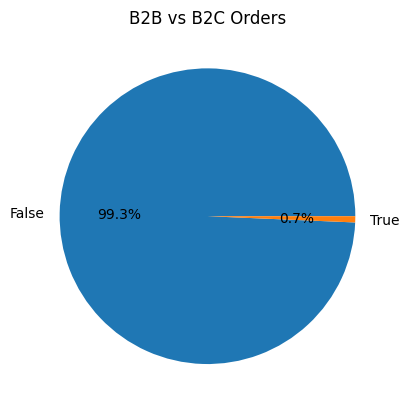

In [43]:
df['B2B'].value_counts().plot(kind='pie',autopct='%1.1f%%')

plt.title("B2B vs B2C Orders")
plt.ylabel("")
plt.show()

Insight: Understands customer type distribution.

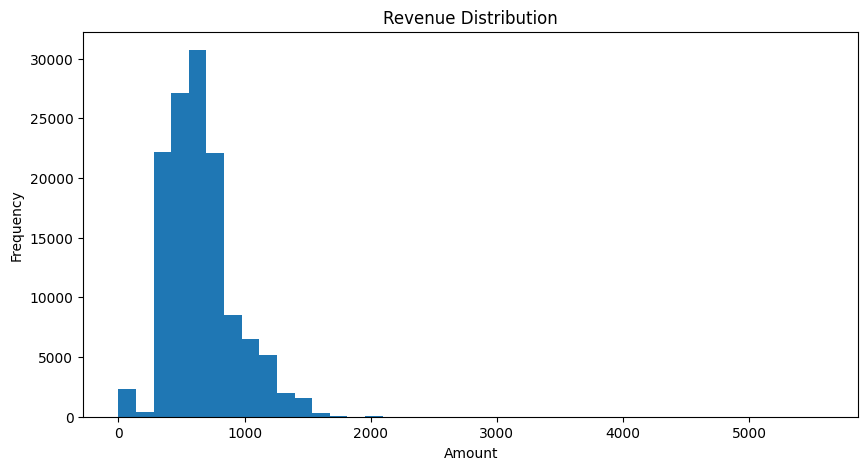

In [44]:
plt.figure(figsize=(10,5))

plt.hist(df['Amount'],bins=40)

plt.title("Revenue Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

insight: Reveals spending patterns and skewness.

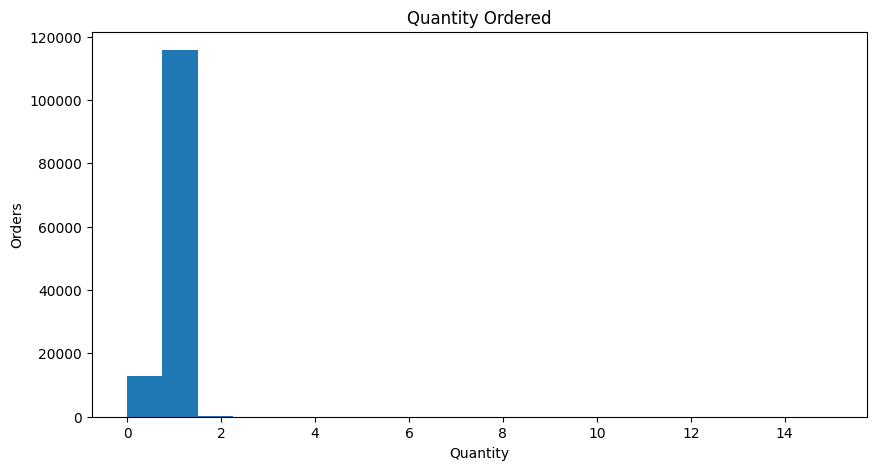

In [45]:
plt.figure(figsize=(10,5))

plt.hist(df['Qty'],bins=20)

plt.title("Quantity Ordered")

plt.xlabel("Quantity")

plt.ylabel("Orders")

plt.show()

Insight: Most orders are expected to have a quantity of 1 or 2.

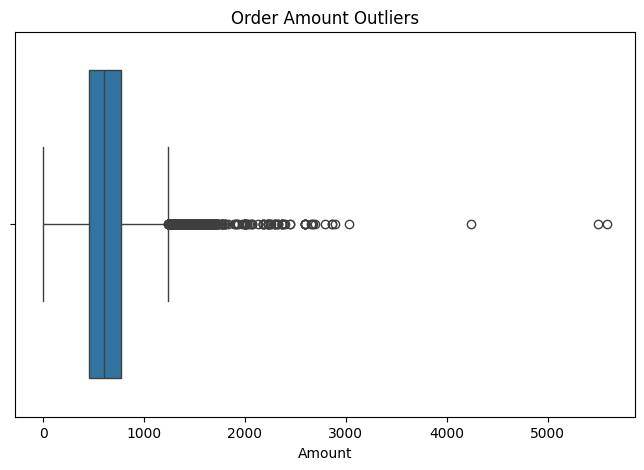

In [46]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Amount'])

plt.title("Order Amount Outliers")

plt.show()

Insight: Detects unusually high-value orders.

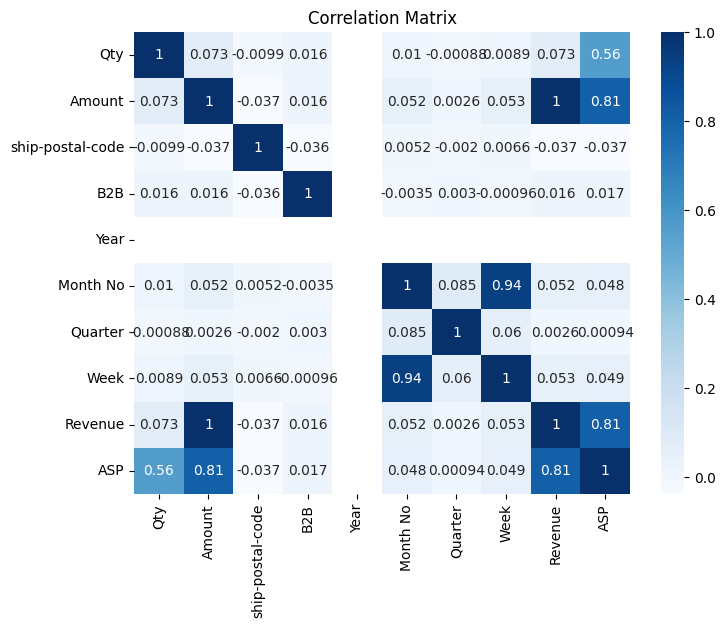

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

Insight: Shows relationships among numerical variables such as Amount, Qty, and postal code.

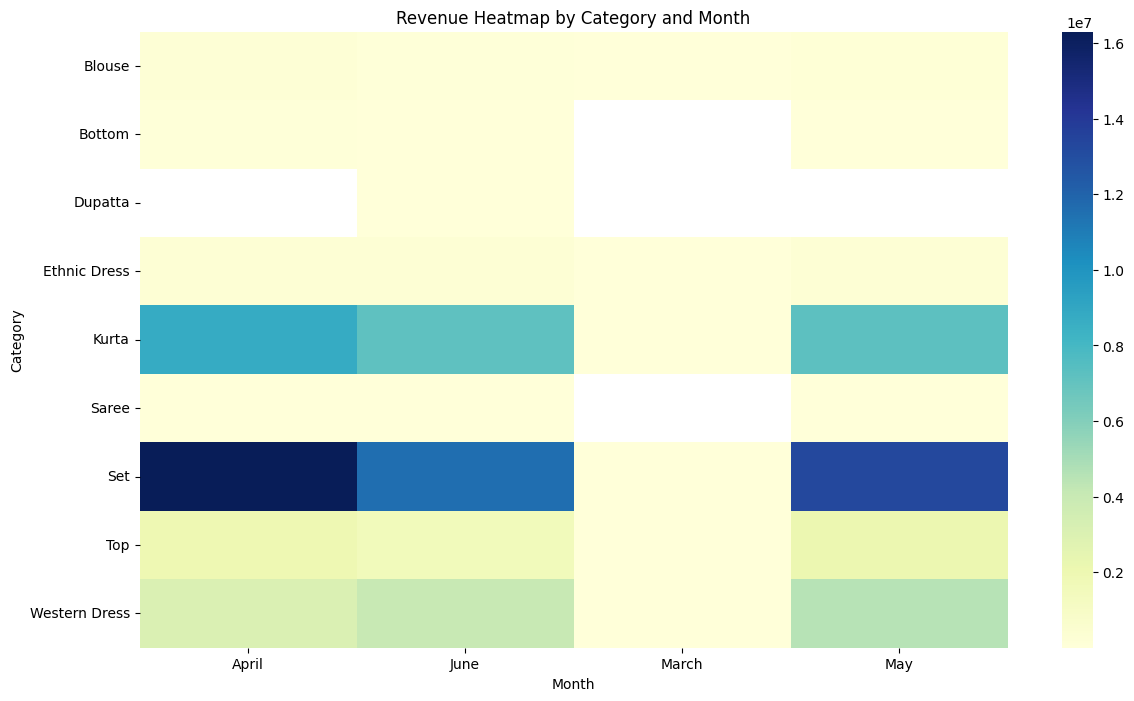

In [48]:
pivot = df.pivot_table(
    values='Amount',
    index='Category',
    columns='Month',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title("Revenue Heatmap by Category and Month")
plt.show()

Business Insight

Seasonal demand
Inventory planning
Festive sales

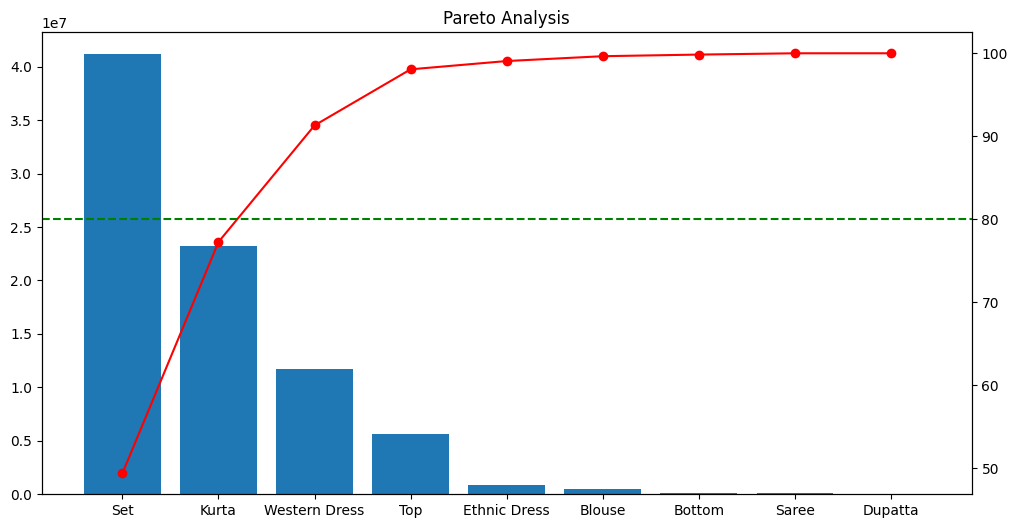

In [50]:
category = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

cum = category.cumsum()/category.sum()*100

fig,ax=plt.subplots(figsize=(12,6))

ax.bar(category.index,category.values)

ax2=ax.twinx()

ax2.plot(category.index,cum,color='red',marker='o')

ax2.axhline(80,color='green',linestyle='--')

plt.xticks(rotation=45)

plt.title("Pareto Analysis")

plt.show()

Shows whether 20% of products generate 80% of revenue.

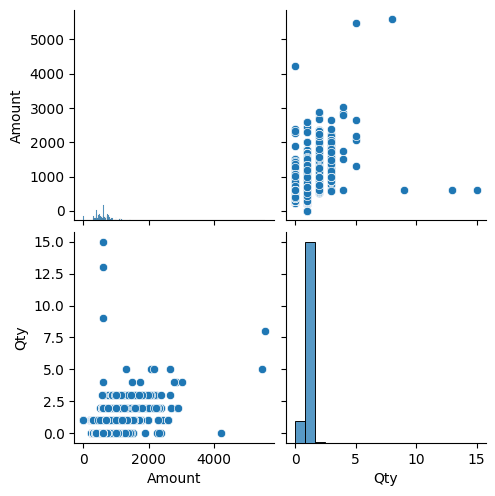

In [54]:
sns.pairplot(
df[
['Amount',
'Qty']
]
)

<Axes: xlabel='Category', ylabel='Amount'>

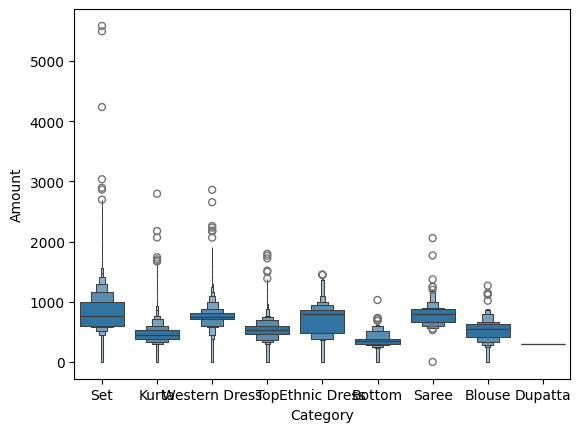

In [55]:
sns.boxenplot(
x='Category',
y='Amount',
data=df
)

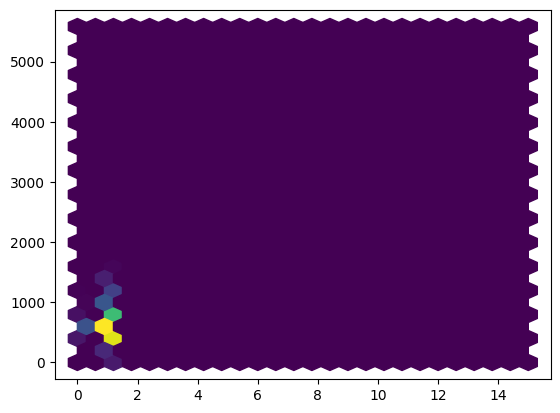

In [56]:
plt.hexbin(
df['Qty'],
df['Amount'],
gridsize=25
)

| **KPI**                             | **Description**                                                                |
| ----------------------------------- | ------------------------------------------------------------------------------ |
| **Total Revenue**                   | Total income generated from all completed and processed orders.                |
| **Total Orders**                    | Total number of unique orders placed by customers.                             |
| **Average Order Value (AOV)**       | Average amount spent by customers per order.                                   |
| **Total Quantity Sold**             | Total number of products sold across all orders.                               |
| **Cancellation Rate**               | Percentage of orders that were cancelled out of the total orders.              |
| **Return Rate**                     | Percentage of orders returned by customers after shipment or delivery.         |
| **Delivery Rate**                   | Percentage of orders successfully delivered to customers.                      |
| **Cancelled Revenue**               | Total revenue lost due to cancelled orders.                                    |
| **B2B Revenue**                     | Revenue generated from Business-to-Business (B2B) customers.                   |
| **B2C Revenue**                     | Revenue generated from Business-to-Consumer (B2C) customers.                   |
| **Top Selling Category**            | Product category generating the highest revenue.                               |
| **Top Selling State**               | State contributing the highest sales revenue.                                  |
| **Top Selling City**                | City with the highest revenue contribution.                                    |
| **Top Fulfilment Method**           | Fulfilment channel (Amazon or Merchant) handling the highest number of orders. |
| **Promotion Usage Rate**            | Percentage of orders placed using promotional offers or discounts.             |
| **Average Quantity per Order**      | Average number of items purchased in each order.                               
Most Preferred Shipping Service Shipping service level most frequently selected by customers.                  
Customer Type Distribution Percentage of B2B versus B2C orders.                                           |

